## Разрешение зависимостей для работы

In [1]:
# !apt install ffmpeg xvfb python-opengl # для UNIX-подобных операционных систем
# !brew install XQuartz # для использования xvfb в MacOS сервере (не опробовано)
# !pip install piglet pyvirtualdisplay
# !pip install gymnasium

In [2]:
# from pyvirtualdisplay import Display # для визуализации на UNIX-подобном сервере


# virtual_display = Display(visible=0, size=(1920, 1080))
# virtual_display.start()

Скрыть предупреждения:

In [3]:
import warnings


warnings.filterwarnings("ignore")

Подключение основных библиотек, в комментариях код для запуска ноутбука на `Unix`-сервере (необходим для отображения работы `RL`-среды)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# В Google Colab или на Unix-сервере (альтернатива pyvirtualdisplay), раскоментируйте код ниже:
# !wget https://bit.ly/2FMJP5K -O setup.py && bash setup.py # после этого переустановать gymnasium

# Данный код создаёт виртуальный экран для отрисовки фреймов игры.
# При локальном запуске можно проигнорировать
# import os
# if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
#     !bash ../xvfb start
#     os.environ['DISPLAY'] = ':1'

### Библиотека [Gymnasium](https://github.com/Farama-Foundation/Gymnasium)

Ближайшее время мы будем изучать алгоритмы процессов принятия решений. Для этого нам потребуются интересные задачи.

Вот тут-то `Gymnasium` и выходит на сцену. Это библиотека на языке программирования Python, в которой имплементированы многие классические задачи, завязанные на принятии решений: управление роботом, видеоигровые среды, настольные игры и т.д.

Взглянем на работу библиотеки со средой [MountainCar-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car/):

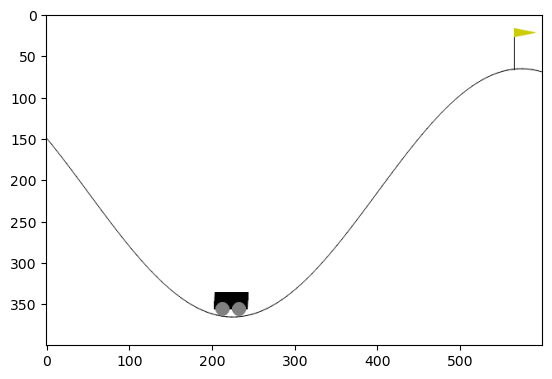

Пространство наблюдений: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Пространство действий: Discrete(3)


In [5]:
import gymnasium as gym


env = gym.make("MountainCar-v0", render_mode="rgb_array").env
env.reset()

plt.imshow(env.render())
plt.show()
print("Пространство наблюдений:", env.observation_space)
print("Пространство действий:", env.action_space)

env.close()

Замечание: если запускаете локально, то может выскочить окно с изображением выше. Не закрывайте его до конца работы ноутбука, так как в противном случае ядро Python может отключиться. Просто переключитесь обратно на данный ноутбук.

### Интерфейс Gymnasium

Три главных метода среды:
* __reset()__ - перезагрузка среды на начальное состояние, _возвращает первое состояние_
* __render()__ - демонстрирует текущее состояние среды (в более цветном виде :) )
* __step(a)__ - совершает действие __a__ и возвращает кортеж (new observation, reward, terminated, truncated, info)
 * _new observation_ - состояние, в которое переходит среда из-за выполнения действия __a__
 * _reward_ - числовая характеристика полезности действия __a__
 * _terminated_ - равно True, если MDP достиг терминального состояния, False иначе
 * _truncated_ – равно True, если MDP прерван (обычно по превышению количества шагов взаимодействия со средой), False иначе
 * _info_ - мета-информация о состяниях и о совершённом действии. Можно игнорировать ~~пока~~.

In [6]:
obs0, info = env.reset()
print("Начальное состояние:", obs0)

# Замечание: в MountainCar, состояние --- два числа: позиция автомобиля и его скорость

Начальное состояние: [-0.53990585  0.        ]


In [7]:
print("выполнение действия под кодом '2' (движение вправо)")
new_obs, reward, terminated, truncated, info = env.step(2)

print("код нового состояния:", new_obs)
print("награда:", reward)
print("игра окончена?:", terminated)
print("игра прервана?:", truncated)
print("мета-информация о состоянии среды в момент совершённого перехода:", info)

# Замечание: как видите, машина сдвинулась немного вправо (около 0.001 условных единиц измерения)

выполнение действия под кодом '2' (движение вправо)
код нового состояния: [-0.5387836   0.00112225]
награда: -1.0
игра окончена?: False
игра прервана?: False
мета-информация о состоянии среды в момент совершённого перехода: {}


### Сыграем

Ниже код, направляющий машину вправо (не монотонно). В коде реализована примитивная стратегия, учитывающая гравитацию на пути машины.

__Замечание__: ваше действие на каждом шагу должно зависеть либо от `t`, либо от `s`.

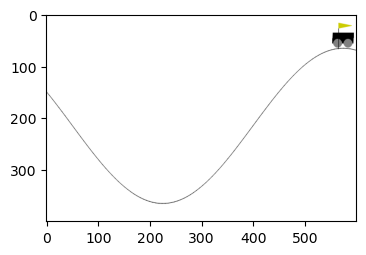

Отлично справились!


In [8]:
from IPython import display


# создаём среду env вручную, устанавливая ограниченную длину эпизода.
TIME_LIMIT = 250
env = gym.wrappers.TimeLimit(
    gym.envs.classic_control.MountainCarEnv(render_mode="rgb_array"),
    max_episode_steps=TIME_LIMIT + 1,
)
s, info = env.reset()
actions = {'left': 0, 'stop': 1, 'right': 2}

plt.figure(figsize=(4, 3))
display.clear_output(wait=True)

for t in range(TIME_LIMIT):
    plt.gca().clear()
    
    # сама стратегия
    if t < 40 or t > 80:
        s, r, terminated, truncated, info = env.step(actions['right'])
    else:
        s, r, terminated, truncated, info = env.step(actions['left'])

    # отрисовка фрейма игры на дисплее
    plt.imshow(env.render())
    
    display.clear_output(wait=True)
    display.display(plt.gcf())

    if terminated:
        print("Отлично справились!")
        break
    if truncated:
        print("Симуляция завершилась преждевременно!")
        break
else:
    print("Время истекло. Попробуйте заново.")

display.clear_output(wait=True)

In [9]:
assert s[0] > .5
print("Вы решили задачу!")

Вы решили задачу!


In [10]:
t

121